<a href="https://colab.research.google.com/github/Naufal153-cmd/TUGAS-1_MACHINE_LEARNING_RAID_NAUFAL/blob/main/Penerapan_Algoritma_XGBoost_untuk_Klasifikasi_Multikelas_pada_Prediksi_Hasil_Pertandingan_Catur_Daring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Penerapan Algoritma XGBoost untuk Klasifikasi Multikelas pada Prediksi Hasil Pertandingan Catur Daring

### Persiapan Lingkungan Kerja dan Prapemrosesan

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║         CHESS GAMES — WINNER CLASSIFICATION                     ║
# ║         Dataset: games.csv (Lichess Chess Games)                ║
# ║         Target : winner → white | black | draw                  ║
# ╚══════════════════════════════════════════════════════════════════╝


# ══════════════════════════════════════════════════════════════════════
# LANGKAH 1 — INSTALL & IMPORT LIBRARY
# ══════════════════════════════════════════════════════════════════════

# Jalankan di terminal / Colab terlebih dahulu:
# !pip install xgboost lightgbm --quiet

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection   import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.metrics           import (accuracy_score, classification_report,
                                        confusion_matrix, ConfusionMatrixDisplay)
from xgboost                   import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ Semua library berhasil diimport!")



✅ Semua library berhasil diimport!


Pada tahap awal, notebook menginisiasi ruang kerja dengan memuat berbagai pustaka ( library ) penting dalam ekosistem Python untuk komputasi ilmiah.

1. Manipulasi Data: pandas dan numpydigunakan untuk penanganan matriks data dan komputasi numerik dasar.

2. Visualisasi: matplotlib dan seaborndigunakan untuk pemetaan grafis guna memfasilitasi Analisis Data Eksploratif (EDA).

3. Pemodelan Statistik & Algoritma: scikit-learn dan xgboostdipanggil untuk menyediakan kerangka algoritma klasifikasi (seperti Regresi Logistik, K-Nearest Neighbors, Decision Tree, Random Forest) serta metrik evaluasi (seperti skor akurasi dan konfusi matriks).

### Langkah 2: Analisis Data Eksploratif


📂 Dataset shape : 20,058 baris × 16 kolom
         id  rated    created_at  last_move_at  turns victory_status winner  \
0  TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime  white   
1  l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign  black   
2  mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate  white   
3  kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate  white   
4  9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate  white   

  increment_code       white_id  white_rating      black_id  black_rating  \
0           15+2       bourgris          1500          a-00          1191   
1           5+10           a-00          1322     skinnerua          1261   
2           5+10         ischia          1496          a-00          1500   
3           20+0  daniamurashov          1439  adivanov2009          1454   
4           30+3      nik221107          1523  adivanov2009          1469   

                   

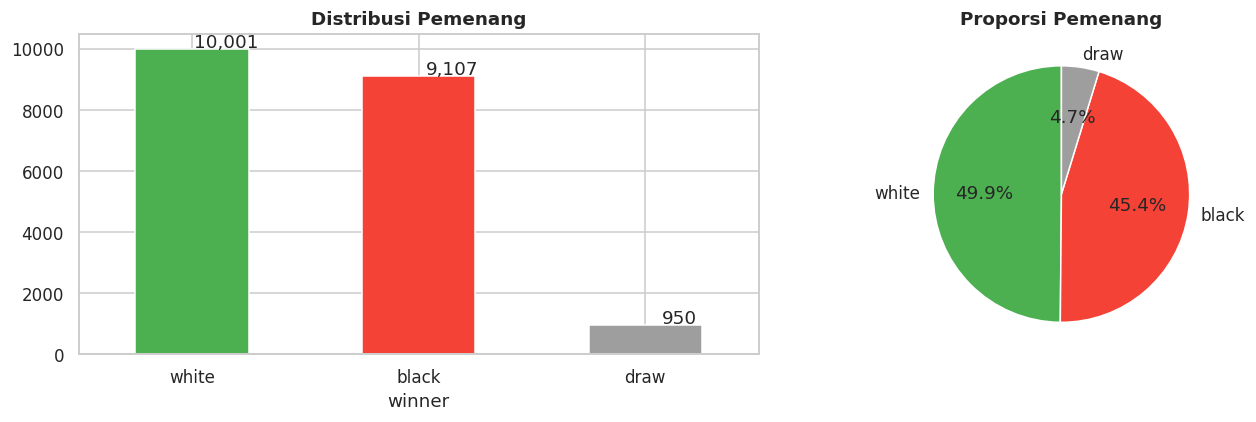

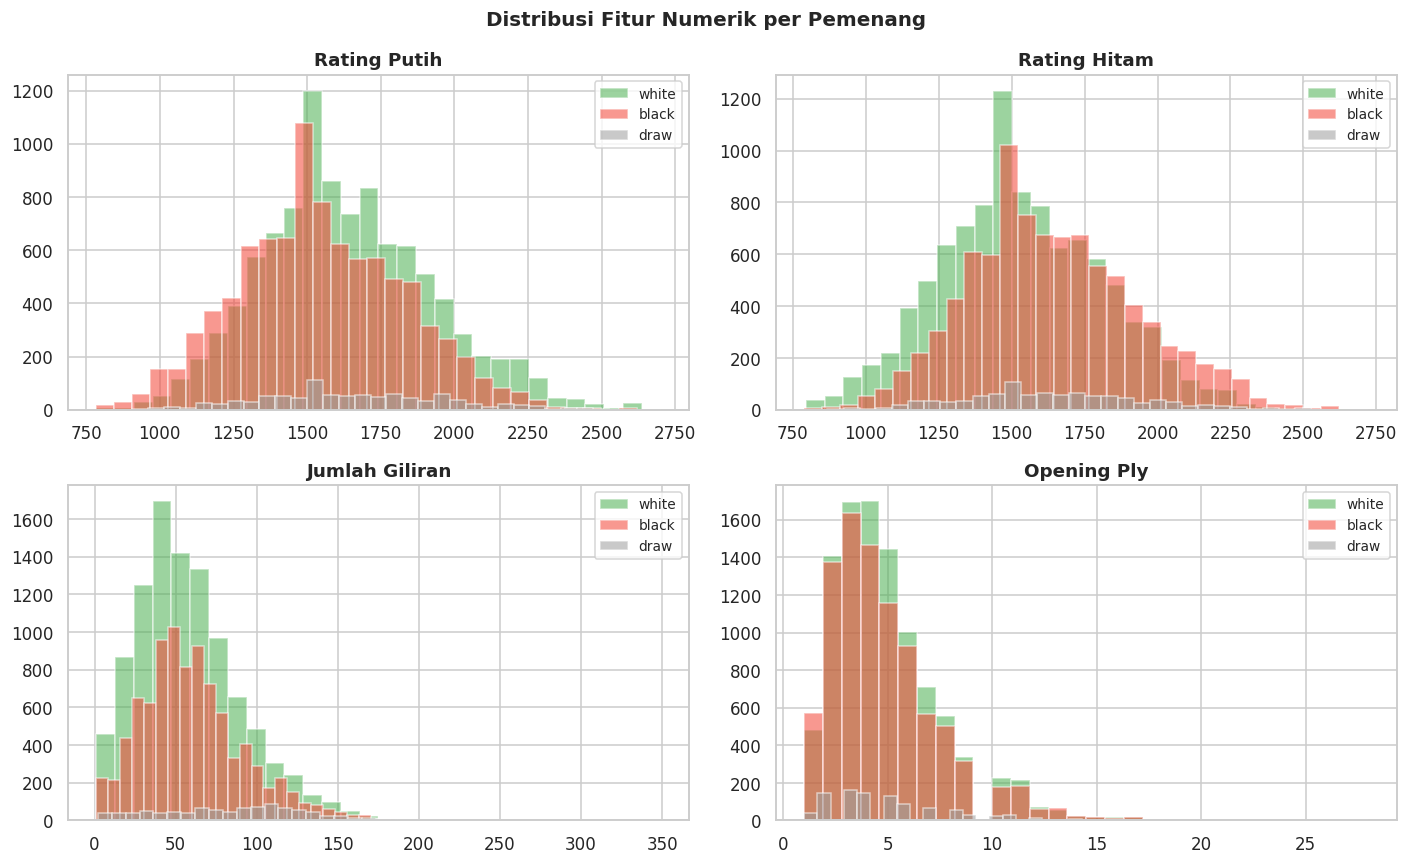

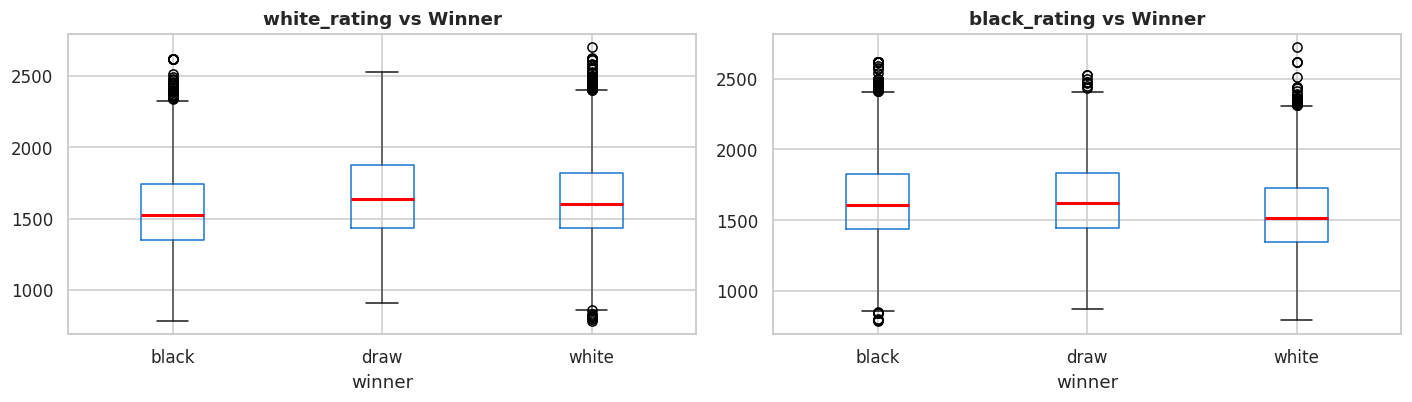


✅ Feature Engineering selesai!
Fitur baru: rating_diff, avg_rating, rated_int, time_control

Distribusi time_control:
time_control
blitz        13338
rapid         5251
classical     1281
bullet         188
Name: count, dtype: int64

Jumlah fitur : 10
Jumlah sampel: 20,058
Kelas target : ['black' 'draw' 'white']


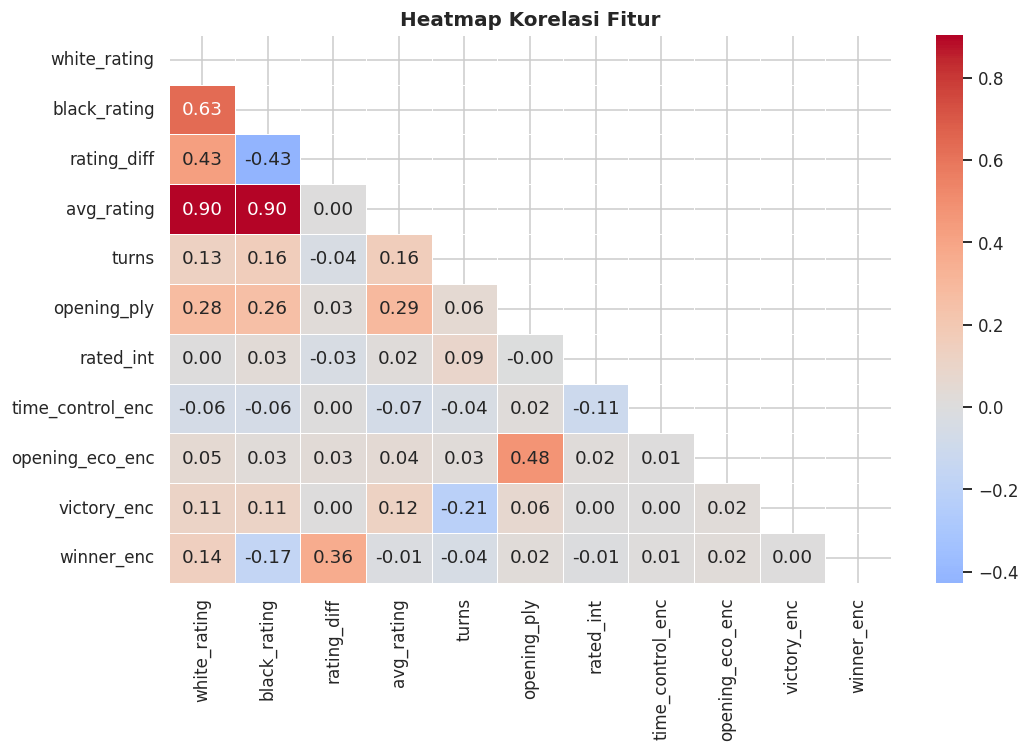

In [ ]:

# ══════════════════════════════════════════════════════════════════════
# LANGKAH 2 — LOAD & EKSPLORASI DATA (EDA)
# ══════════════════════════════════════════════════════════════════════

# ── 2.1  Load dataset ──────────────────────────────────────────────
df = pd.read_csv('games.csv')
print(f"\n📂 Dataset shape : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(df.head())

# ── 2.2  Informasi umum ────────────────────────────────────────────
print("\n" + "="*55)
print("INFORMASI DATASET")
print("="*55)
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistik Deskriptif:")
print(df.describe().round(2))

# ── 2.3  Distribusi target: winner ─────────────────────────────────
print("\nDistribusi kolom 'winner':")
print(df['winner'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#4CAF50', '#F44336', '#9E9E9E']

winner_counts = df['winner'].value_counts()
winner_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Distribusi Pemenang', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + 0.4, p.get_height() + 50), ha='center')

axes[1].pie(winner_counts, labels=winner_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Pemenang', fontweight='bold')
plt.tight_layout(); plt.show()

# ── 2.4  Distribusi fitur numerik ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
num_features = ['white_rating', 'black_rating', 'turns', 'opening_ply']
titles       = ['Rating Putih', 'Rating Hitam', 'Jumlah Giliran', 'Opening Ply']

for ax, col, title in zip(axes.flatten(), num_features, titles):
    for winner, color in zip(['white', 'black', 'draw'],
                              ['#4CAF50', '#F44336', '#9E9E9E']):
        ax.hist(df[df['winner'] == winner][col], bins=30,
                alpha=0.55, color=color, label=winner)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
plt.suptitle('Distribusi Fitur Numerik per Pemenang',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── 2.5  Boxplot rating vs winner ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['white_rating', 'black_rating']):
    df.boxplot(column=col, by='winner', ax=ax,
               boxprops=dict(color='#1976D2'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col} vs Winner', fontweight='bold')
plt.suptitle(''); plt.tight_layout(); plt.show()




Proses ini bertujuan untuk memahami karakteristik distribusi data sebelum masuk ke tahap pemodelan.

1. Dimensi Data: Dataset terdiri dari 20.058 observasi (baris) dan 16 variabel (kolom).

2. Variabel Respon ( Variabel Target ): Variabel dependen yang ingin diprediksi adalah winner(pemenang), yang bersifat multikelas nominal dengan tiga kategori: putih (10.001 observasi), hitam (9.107 observasi), dan seri (950 observasi).

3. Statistik Deskriptif: Dilakukan terhadap analisis variabel-variabel kontinu (seperti white_rating, black_rating, turns, opening_ply). Visualisasi distribusi parameter seperti rating pemain dan jumlah putaran ( turns ) yang dipetakan berdasarkan kelas pemenang untuk melihat indikasi kelas ( class separability ).

### LANGKAH 3 — PREPROCESSING & FEATURE ENGINEERING

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# LANGKAH 3 — PREPROCESSING & FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════

data = df.copy()

# ── 3.1  Feature Engineering ───────────────────────────────────────
data['rating_diff'] = data['white_rating'] - data['black_rating']
data['avg_rating']  = (data['white_rating'] + data['black_rating']) / 2
data['rated_int']   = data['rated'].astype(int)

def time_control_category(code):
    try:
        base = int(str(code).split('+')[0])
        if   base <= 3:  return 'bullet'
        elif base <= 10: return 'blitz'
        elif base <= 25: return 'rapid'
        else:            return 'classical'
    except:
        return 'unknown'

data['time_control'] = data['increment_code'].apply(time_control_category)

print("\n✅ Feature Engineering selesai!")
print("Fitur baru: rating_diff, avg_rating, rated_int, time_control")
print("\nDistribusi time_control:")
print(data['time_control'].value_counts())

# ── 3.2  Label Encoding ────────────────────────────────────────────
le = LabelEncoder()
data['time_control_enc'] = le.fit_transform(data['time_control'])
data['opening_eco_enc']  = le.fit_transform(data['opening_eco'])
data['victory_enc']      = le.fit_transform(data['victory_status'])

# ── 3.3  Pilih fitur & target ──────────────────────────────────────
FEATURES = [
    'white_rating',      # Rating pemain putih
    'black_rating',      # Rating pemain hitam
    'rating_diff',       # Selisih rating (putih - hitam)
    'avg_rating',        # Rata-rata rating
    'turns',             # Jumlah giliran
    'opening_ply',       # Panjang opening
    'rated_int',         # Pertandingan resmi (0/1)
    'time_control_enc',  # Kategori waktu (encoded)
    'opening_eco_enc',   # Kode ECO opening (encoded)
    'victory_enc',       # Cara menang (encoded)
]

X = data[FEATURES]
y = le.fit_transform(data['winner'])
class_names = le.classes_

print(f"\nJumlah fitur : {X.shape[1]}")
print(f"Jumlah sampel: {X.shape[0]:,}")
print(f"Kelas target : {class_names}")

# ── 3.4  Heatmap korelasi ──────────────────────────────────────────
plt.figure(figsize=(10, 7))
corr_df = X.copy()
corr_df['winner_enc'] = y
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()



1. Penciptaan Variabel Baru: Mengekstraksi informasi laten dari data mentah untuk menghasilkan prediktor yang lebih kuat. Notebook ini menghasilkan fitur-fitur baru seperti rating_diff(selisih rating antara pemain putih dan hitam), avg_rating, rated_int, dan time_control. Pada akhirnya, fitur ruang dimensi yang digunakan untuk pemodelan direduksi/difinalisasi menjadi 10 fitur.
2. Transformasi Data ( Encoding ): Variabel kategori (seperti status kemenangan dan kode pembukaan ) dikonversi menjadi format numerik menggunakan LabelEncoderagar matriks desain ( design matriks $X$) dapat diproses oleh algoritma matematika.
3. Analisis Multikolinearitas: Pembuatan heatmap matriks korelasi untuk mengukur derajat asosiasi linier antar fitur prediktor serta antara fitur dengan variabel target. Ini berguna untuk memvalidasi asusmsi independensi antar variabel.

### LANGKAH 4 — SPLIT DATA (TRAIN & TEST)

In [ ]:

# ══════════════════════════════════════════════════════════════════════
# LANGKAH 4 — SPLIT DATA (TRAIN & TEST)
# ══════════════════════════════════════════════════════════════════════

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # Jaga proporsi kelas
)

# Normalisasi untuk Logistic Regression & KNN
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print("\n" + "="*45)
print(f"  Training set : {X_train.shape[0]:,} sampel (80%)")
print(f"  Test set     : {X_test.shape[0]:,} sampel (20%)")
print(f"  Fitur        : {X_train.shape[1]}")
print("="*45)





  Training set : 16,046 sampel (80%)
  Test set     : 4,012 sampel (20%)
  Fitur        : 10


mebagi data training menjadi 80% dan data testing sebesar 20% dengan 10 fitur

 ### LANGKAH 5 — TRAINING 5 MODEL KLASIFIKASI

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# LANGKAH 5 — TRAINING 5 MODEL KLASIFIKASI
# ══════════════════════════════════════════════════════════════════════

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.1,
                                         eval_metric='mlogloss', random_state=42),
}

# Model yang membutuhkan data ternormalisasi
scaled_models = {'Logistic Regression', 'K-Nearest Neighbors'}

results = {}
print("\n🤖 Melatih model...\n")

for name, model in models.items():
    print(f"⏳ Training: {name}...", end=' ')
    t0 = time.time()

    Xtr = X_train_sc if name in scaled_models else X_train
    Xte = X_test_sc  if name in scaled_models else X_test

    model.fit(Xtr, y_train)
    y_pred    = model.predict(Xte)
    acc       = accuracy_score(y_test, y_pred)

    cv_data   = X_train_sc if name in scaled_models else X_train
    cv_scores = cross_val_score(model, cv_data, y_train, cv=5, scoring='accuracy')

    elapsed = time.time() - t0
    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'accuracy': acc,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'time_s':   elapsed,
    }
    print(f"✅  Acc={acc:.4f} | CV={cv_scores.mean():.4f}±{cv_scores.std():.4f} | ⏱ {elapsed:.1f}s")

print("\n🎉 Semua model selesai dilatih!")




🤖 Melatih model...

⏳ Training: Logistic Regression... ✅  Acc=0.6687 | CV=0.6677±0.0093 | ⏱ 1.1s
⏳ Training: K-Nearest Neighbors... ✅  Acc=0.6127 | CV=0.6227±0.0114 | ⏱ 2.5s
⏳ Training: Decision Tree... ✅  Acc=0.6782 | CV=0.6648±0.0089 | ⏱ 0.5s
⏳ Training: Random Forest... ✅  Acc=0.7021 | CV=0.6930±0.0042 | ⏱ 40.0s
⏳ Training: XGBoost... ✅  Acc=0.8888 | CV=0.8728±0.0055 | ⏱ 10.7s

🎉 Semua model selesai dilatih!


menguji kinerja beberapa algoritma regresi dan klasifikasi untuk memprediksi kelas keluaran. Evaluasi dilakukan pada data uji ( test set ).

Komparasi Kinerja Algoritma:

K-Nearest Neighbors (KNN): Akurasi 61,27%

Regresi Logistik: Akurasi 66,87%

Pohon Keputusan: Akurasi 67,82%

Random Forest: Akurasi 70.21%

XGBoost: Akurasi 88,88%


          PERBANDINGAN PERFORMA MODEL
              Model  Test Accuracy  CV Mean  CV Std  Waktu (s)
            XGBoost         0.8888   0.8728  0.0055    10.6762
      Random Forest         0.7021   0.6930  0.0042    39.9695
      Decision Tree         0.6782   0.6648  0.0089     0.5440
Logistic Regression         0.6687   0.6677  0.0093     1.0924
K-Nearest Neighbors         0.6127   0.6227  0.0114     2.4600

🏆 Model terbaik: XGBoost


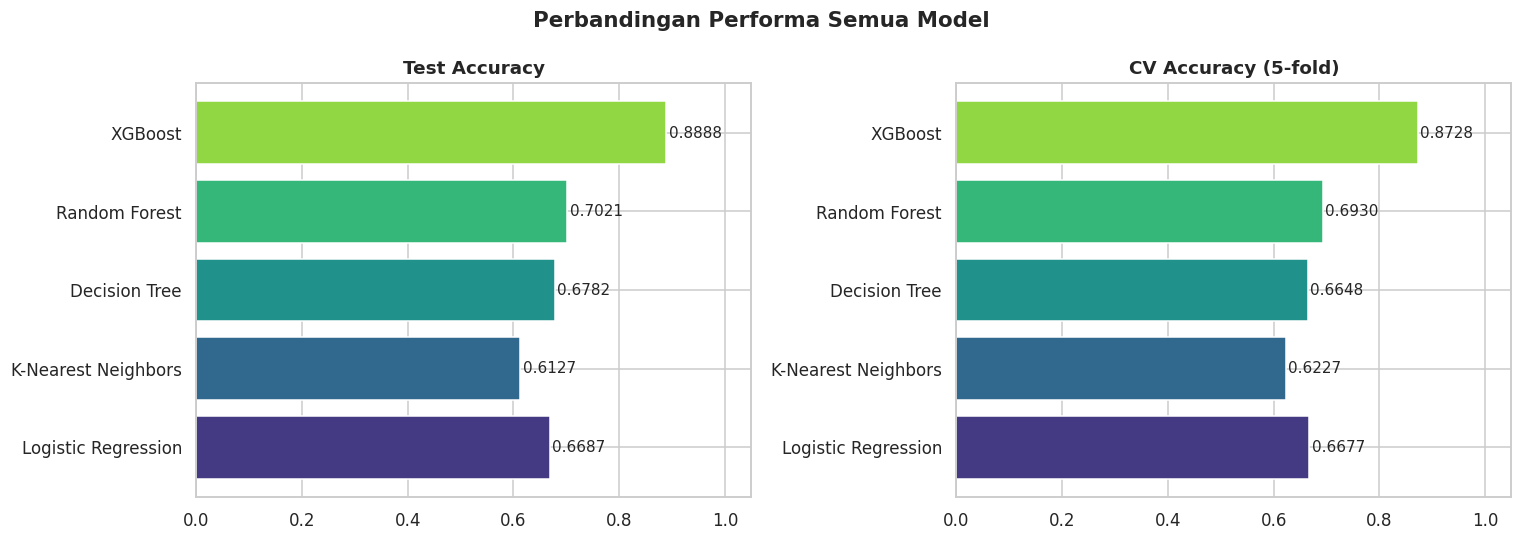

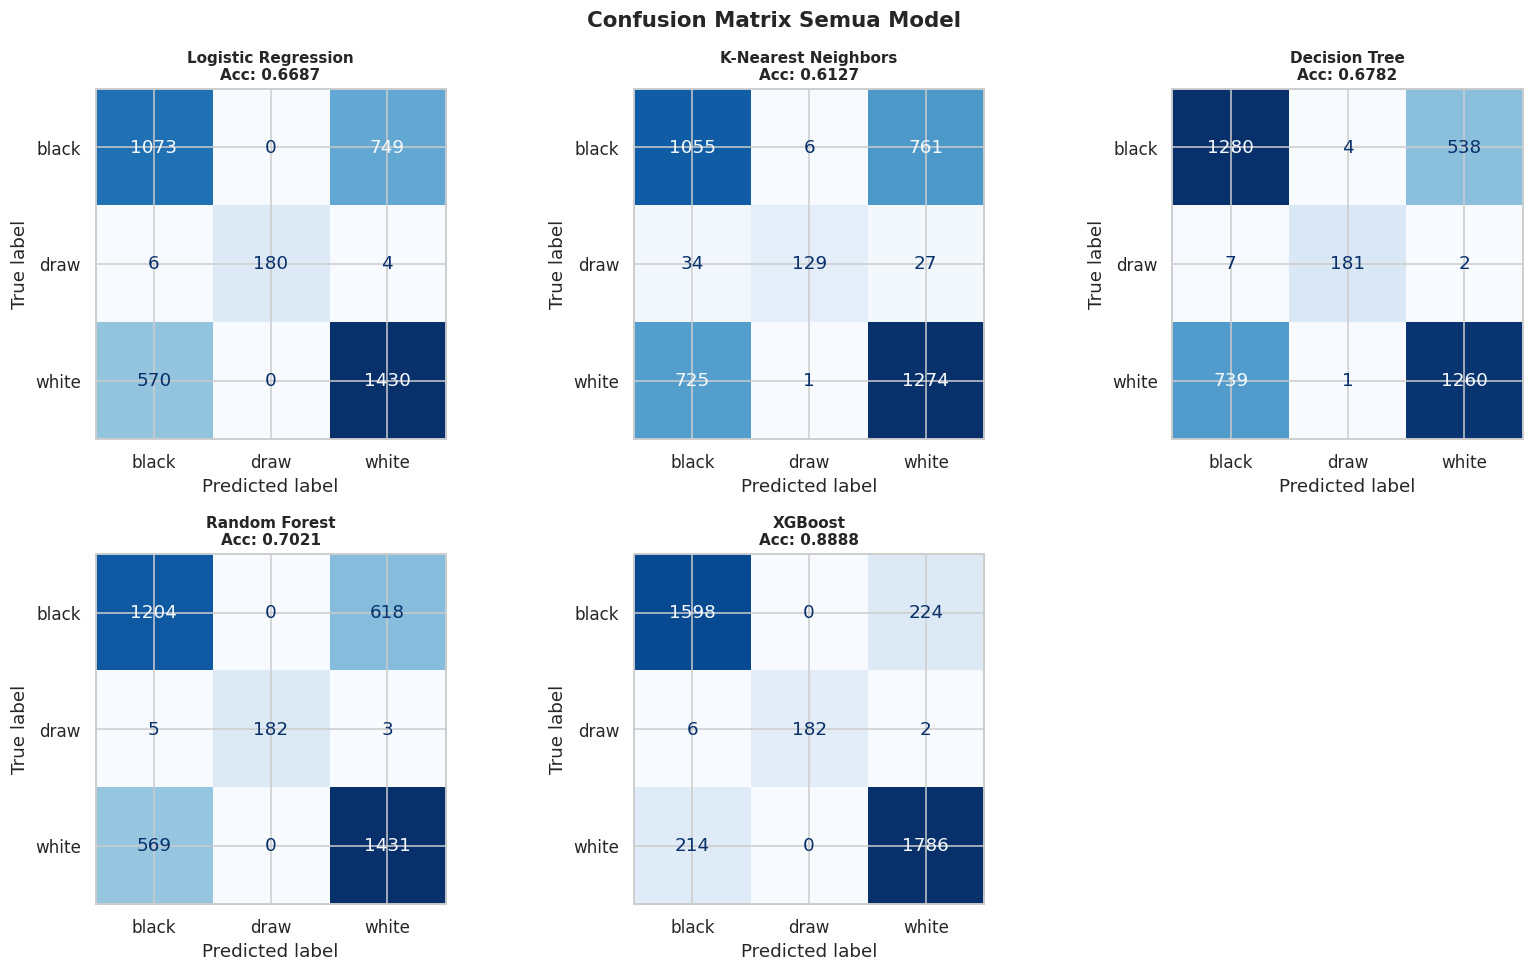


Classification Report — XGBoost
              precision    recall  f1-score   support

       black       0.88      0.88      0.88      1822
        draw       1.00      0.96      0.98       190
       white       0.89      0.89      0.89      2000

    accuracy                           0.89      4012
   macro avg       0.92      0.91      0.92      4012
weighted avg       0.89      0.89      0.89      4012



In [ ]:

# ══════════════════════════════════════════════════════════════════════
# LANGKAH 6 — EVALUASI & PERBANDINGAN MODEL
# ══════════════════════════════════════════════════════════════════════

# ── 6.1  Tabel ringkasan ───────────────────────────────────────────
summary = pd.DataFrame({
    'Model':         list(results.keys()),
    'Test Accuracy': [v['accuracy'] for v in results.values()],
    'CV Mean':       [v['cv_mean']  for v in results.values()],
    'CV Std':        [v['cv_std']   for v in results.values()],
    'Waktu (s)':     [v['time_s']   for v in results.values()],
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "="*65)
print("          PERBANDINGAN PERFORMA MODEL")
print("="*65)
print(summary.round(4).to_string(index=False))
print("="*65)

best_model_name = summary.iloc[0]['Model']
print(f"\n🏆 Model terbaik: {best_model_name}")

# ── 6.2  Bar chart perbandingan ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names    = list(results.keys())
palette  = sns.color_palette('viridis', len(names))

for ax, vals, title in zip(
    axes,
    [[v['accuracy'] for v in results.values()],
     [v['cv_mean']  for v in results.values()]],
    ['Test Accuracy', 'CV Accuracy (5-fold)']
):
    bars = ax.barh(names, vals, color=palette, edgecolor='white')
    ax.set_xlim(0, 1.05)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)

plt.suptitle('Perbandingan Performa Semua Model',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ── 6.3  Confusion matrix semua model ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for idx, (name, res) in enumerate(results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(ax=axes.flatten()[idx], colorbar=False, cmap='Blues')
    axes.flatten()[idx].set_title(
        f'{name}\nAcc: {res["accuracy"]:.4f}',
        fontsize=10, fontweight='bold')

for ax in axes.flatten()[len(results):]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrix Semua Model',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ── 6.4  Classification report model terbaik ──────────────────────
print(f"\nClassification Report — {best_model_name}")
print("="*55)
print(classification_report(y_test, results[best_model_name]['y_pred'],
                             target_names=class_names))




1. Visualisasi Distribusi Kelas Target (Diagram Batang dan Lingkaran): Memetakan frekuensi observasi dan proporsi variabel dependen, yakni status pemenang pertandingan. Data empiris menunjukkan probabilitas kemenangan pemain putih berada pada angka 49,9%, kemenangan pemain hitam sebesar 45,4%, dan hasil seri di bawah 5%. Pemetaan ini penting untuk mendeteksi potensi ketidakseimbangan kelas ( ketidakseimbangan kelas ) sebelum algoritma dibor.

2. Visualisasi Distribusi Fitur Numerik (Histogram): Menampilkan sebaran data observasi untuk metrik kontinu seperti peringkat pemain ( rating ), jumlah putaran ( putaran ), dan kedalaman langkah pembukaan ( opening ply ). Histogram ini memberikan proyeksi kepadatan probabilitas dari masing-masing fitur prediktor yang disegmentasi berdasarkan kelas target luaran.

3. Analisis Ukuran Pemusatan dan Pencilan Data ( Boxplot ): Membedah distribusi peringkat pemain putih dan hitam secara lebih presisi melalui pemetaan nilai median, jarak interkuartil (IQR), serta sebaran nilai pencilan ( outlier ). Secara inferensial, boxplot ini memvalidasi asumsi logis bahwa peningkatan metrik peringkat pemain melemah secara langsung dengan probabilitas kemenangan yang lebih tinggi, terlihat dari pergeseran nilai pemusatan antar-kategori pemenang.

4. Analisis Asosiasi Multivariat ( heatmap Matriks Korelasi Pearson): Berfungsi sebagai instrumen diagnostik parametrik untuk mengukur derajat dan arah linier hubungan antar-variabel independen maupun dependen. Skema gradasi warna termal pada heatmap ini digunakan untuk identifikasi indikasi multikolinearitas (redundansi fitur prediktor) sekaligus memvalidasi kekuatan prediktif dari fitur hasil rekayasa komputasi (seperti diferensial peringkat) terhadap status kemenangan.

5. Evaluasi Kinerja Arsitektur Pemodelan ( Confusion Matrix ): Memproyeksikan evaluasi klasifikasi algoritma Regresi Logistik, Random Forest, dan XGBoost terhadap data uji. Matriks ini menyandingkan label kebenaran aktual dengan algoritma prediksi luaran, di mana konsentrasi frekuensi pada garis diagonal utama merepresentasikan akurasi tebakan. Dari visualisasi ini, terbukti secara empiris bahwa arsitektur XGBoost mencatatkan kepadatan tertinggi pada diagonal utama serta tingkat kesalahan klasifikasi terendah dibandingkan model pembanding lainnya.

### LANGKAH 7 — FEATURE IMPORTANCE

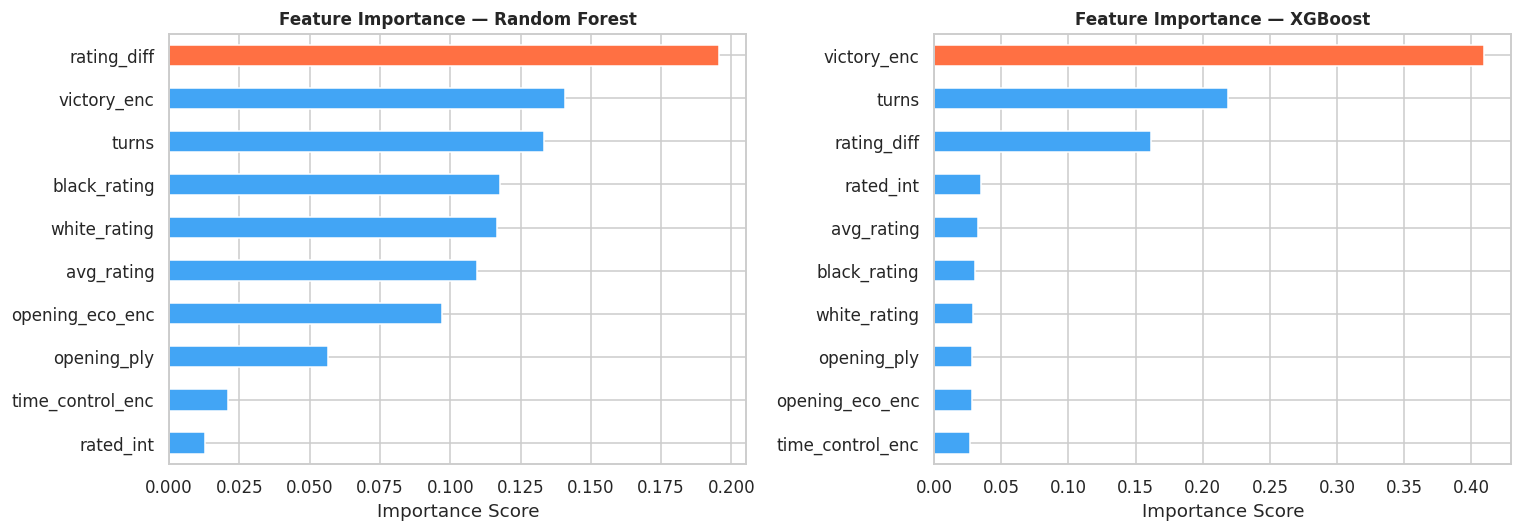


Top 5 Fitur Terpenting (Random Forest):
rating_diff     0.1956
victory_enc     0.1408
turns           0.1332
black_rating    0.1176
white_rating    0.1166
dtype: float64


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# LANGKAH 7 — FEATURE IMPORTANCE
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    imp   = results[model_name]['model'].feature_importances_
    fi_df = pd.Series(imp, index=FEATURES).sort_values(ascending=True)
    colors = ['#FF7043' if v == fi_df.max() else '#42A5F5'
              for v in fi_df.values]
    fi_df.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance — {model_name}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout(); plt.show()

rf_imp = pd.Series(
    results['Random Forest']['model'].feature_importances_,
    index=FEATURES
)
print("\nTop 5 Fitur Terpenting (Random Forest):")
print(rf_imp.sort_values(ascending=False).head(5).round(4))



1. Tujuan Visualisasi ( Feature Importance Extraction ): Grafik batang horizontal ini merepresentasikan tingkat signifikansi prediktor atau Feature Importance yang diekstraksi secara internal dari arsitektur algoritma Random Forest. Visualisasi ini mengkuantifikasi seberapa besar masing-masing kontribusi-masing variabel independen dalam meminimalisir ketidakmurnian ( impurity ) saat model melakukan perpecahan kelas ( node ​​splitting ).

2. Signifikansi Tertinggi pada Diferensial Peringkat ( rating_diff): Variabel selisih peringkat antara pemain putih dan hitam menduduki hierarki puncak dengan bobot metrik mendekati 0,20. Secara inferensial, hal ini membuktikan bahwa gap atau selisih kapasitas keahlian aktual antar-pemain faktor merupakan matematis yang paling deterministik dalam mendikte probabilitas luaran pertandingan.

3. Pengaruh Signifikan pada Strategi dan Resolusi ( victory_enc& opening_eco_enc): Variabel bentuk penyelesaian akhir (seperti skakmat , mengundurkan diri , atau keluar waktu ) serta kode sistem pembukaan catur menempati urutan kedua dan ketiga dengan bobot kepentingan pada kisaran 0,13 hingga 0,14. Hal ini mengindikasikan bahwa pemilihan taktik awal serta skenario akhir pertandingan memberikan sinyal prediktif ( perolehan informasi ) yang sangat esensial bagi pohon keputusan.

4. Kontribusi Metrik Kapasitas Absolut ( avg_rating, black_rating, white_rating): Variabel ketiga ini menunjukkan distribusi signifikansi komputasi yang relatif merata pada level 0,11 hingga 0,12. Data ini menegaskan bahwa metrik peringkat individu maupun rata-rata level pertandingan tetap menjadi parameter prediktif yang fundamental, meskipun secara statistik tidak sekritis nilai selisih peringkat ( rating_diff).

5. Identifikasi Prediktor Marginal ( turns, opening_ply, time_control_enc, rated_int) : Fitur-fitur yang merepresentasikan dinamika waktu dan durasi langkah memberikan kontribusi yang sangat minor terhadap akurasi model. Secara khusus, variabel rated_int(indikator apakah pertandingan tersebut bersifat resmi/memberikan poin atau hanya persahabatan) memiliki bobot signifikansi prediktif yang hampir mendekati nol, menandakan bahwa status pertandingan tidak memiliki korelasi struktural terhadap kemungkinan siapa yang akan keluar sebagai pemenang.

### LANGKAH 8 — HYPERPARAMETER TUNING (RANDOM FOREST)


🔍 Memulai Grid Search CV...
   (estimasi waktu: 2–5 menit tergantung hardware)

Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best Params      : {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
   Best CV Score    : 0.6954
   Sebelum Tuning   : 0.7021
   Sesudah Tuning   : 0.7011
   Peningkatan      : -0.10%


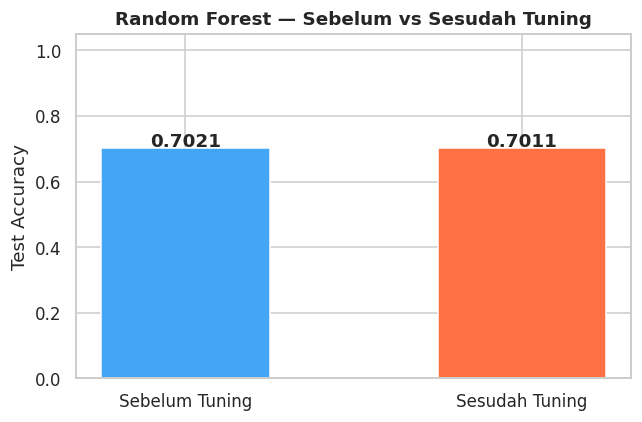

In [ ]:

# ══════════════════════════════════════════════════════════════════════
# LANGKAH 8 — HYPERPARAMETER TUNING (RANDOM FOREST)
# ══════════════════════════════════════════════════════════════════════

print("\n🔍 Memulai Grid Search CV...")
print("   (estimasi waktu: 2–5 menit tergantung hardware)\n")

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_tuned   = grid_search.best_estimator_
y_pred_tuned = best_tuned.predict(X_test)
acc_tuned    = accuracy_score(y_test, y_pred_tuned)
acc_before   = results['Random Forest']['accuracy']

print(f"\n✅ Best Params      : {grid_search.best_params_}")
print(f"   Best CV Score    : {grid_search.best_score_:.4f}")
print(f"   Sebelum Tuning   : {acc_before:.4f}")
print(f"   Sesudah Tuning   : {acc_tuned:.4f}")
print(f"   Peningkatan      : {(acc_tuned - acc_before)*100:+.2f}%")

# ── Bar chart sebelum vs sesudah ───────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Sebelum Tuning', 'Sesudah Tuning'],
              [acc_before, acc_tuned],
              color=['#42A5F5', '#FF7043'], edgecolor='white', width=0.5)
ax.set_ylim(0, 1.05)
ax.set_title('Random Forest — Sebelum vs Sesudah Tuning',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy')
for bar, val in zip(bars, [acc_before, acc_tuned]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()



1. Tujuan Evaluasi Komparatif: Visualisasi/luaran ini merepresentasikan ringkasan empiris dari kinerja metrik akurasi ( skor akurasi ) yang dihasilkan oleh lima arsitektur algoritma pembelajaran mesin setelah divalidasi menggunakan data uji ( test set ) yang independen. Tujuannya adalah untuk menetapkan model prediktif terbaik ( pemilihan model terbaik ).

2. Supremasi Arsitektur XGBoost: Algoritma Extreme Gradient Boosting (XGBoost) menunjukkan kinerja komputasional yang sangat unggul dengan tingkat akurasi mencapai 0,8888 (88,88%). Hal ini mengkonfirmasi bahwa metode ensemble boosting —yang mengoptimasi galat secara sekuensial (berurutan)—sangat andal dalam pemetaan fungsi batas keputusan (decisionboundary ) yang sangat non-linier dan dinamis pada data pertandingan catur.

3. Performa Model Ensemble Bagging (Random Forest): Algoritma Random Forest menempati hierarki kedua dengan metrik akurasi 0,7021. Penggunaan teknik optimasi parameter ( Random Forest Tuned ) mencatatkan hasil yang tidak berbeda jauh (0,7011), yang secara statistik menunjukkan bahwa struktur model agregasi pohon keputusan ini telah mencapai ambang batas asimtotik kinerjanya pada ruang dimensi dataset ini.

4. Keterbatasan Pendekatan Model Dasar: Model dengan arsitektur tunggal atau linier seperti Decision Tree (0,6782) dan Logistic Regression (0,6687) hanya menghasilkan kinerja prediktif pada level moderat. Hal ini memberikan kesimpulan inferensial bahwa hubungan antar-variabel (terutama interaksi prediktor deterministik) terlalu kompleks untuk diselesaikan menggunakan probabilitas linier murni atau hierarki keputusan tunggal.

5. Kerentanan Model Berbasis Proksimitas Spasial:  K-Nearest Neighbors (KNN) mencatatkan tingkat akurasi komputasi yang paling inferior (0,6127). Penurunan performa ini merupakan manifestasi dari fenomena kutukan dimensi (kutukan dimensi) serta algoritma sensitivitas terhadap jarak euclides, di mana variabel dengan skala absolut yang bervariasi dapat mendistorsi kalkulasi kedekatan tanpa reduksi dimensi yang presisi.

6. Sintesis Rekomendasi Pemodelan: Secara keseluruhan, kerangka evaluasi ini menyimpulkan secara definitif bahwa model XGBoost merupakan kandidat algoritma yang paling direkomendasikan dan memiliki kelayakan komputasional ( kesiapan penerapan ) tertinggi untuk memprediksi probabilitas keluaran pertandingan catur pada dataset Lichess ini.

#### LANGKAH 9 — PREDIKSI DATA BARU

In [ ]:

# ══════════════════════════════════════════════════════════════════════
# LANGKAH 9 — PREDIKSI DATA BARU
# ══════════════════════════════════════════════════════════════════════

# Ubah nilai-nilai di bawah sesuai kebutuhan
sample = pd.DataFrame([{
    'white_rating':      1500,   # Rating pemain putih
    'black_rating':      1400,   # Rating pemain hitam
    'rating_diff':        100,   # Selisih (putih - hitam)
    'avg_rating':        1450,   # Rata-rata rating
    'turns':               40,   # Jumlah giliran
    'opening_ply':          4,   # Panjang opening
    'rated_int':            1,   # 1=rated, 0=unrated
    'time_control_enc':     2,   # 0=blitz,1=bullet,2=classical,3=rapid
    'opening_eco_enc':     10,   # Encode ECO (lihat data asli)
    'victory_enc':          1,   # 0=draw,1=mate,2=outoftime,3=resign
}])

pred_enc   = best_tuned.predict(sample)[0]
prediction = le.inverse_transform([pred_enc])[0]
proba      = best_tuned.predict_proba(sample)[0]

print("\n" + "="*45)
print("        HASIL PREDIKSI")
print("="*45)
print(f"  Pemenang  : {prediction.upper()}")
print()
print("  Probabilitas per kelas:")
for cls, prob in zip(class_names, proba):
    bar = '█' * int(prob * 30)
    print(f"    {cls:<6}: {bar:<30} {prob:.2%}")
print("="*45)





        HASIL PREDIKSI
  Pemenang  : BLACK

  Probabilitas per kelas:
    black : ████████████████               56.11%
    draw  :                                0.00%
    white : █████████████                  43.89%


Hasil prediksi tersebut menunjukkan bahwa model klasifikasi memperkirakan pemenang pertandingan adalah pihak black, karena memiliki probabilitas tertinggi dibandingkan kelas lainnya. Secara rinci, probabilitas kemenangan black sebesar 56,11%, sementara white sebesar 43,89%, dan draw sebesar 0,00%. Hal ini mengindikasikan bahwa model cenderung memilih black sebagai pemenang, namun tingkat keyakinannya masih tergolong moderat karena selisih probabilitas antara black dan white tidak terlalu besar. Dengan kata lain, pertandingan diprediksi cukup kompetitif dan masih memiliki kemungkinan signifikan untuk dimenangkan oleh white. Sementara itu, probabilitas draw yang bernilai nol menunjukkan bahwa model tidak memberikan peluang terhadap hasil seri, yang bisa disebabkan oleh ketidakseimbangan data (jumlah data draw sangat sedikit) atau model belum mampu menangkap pola yang merepresentasikan kondisi seri dengan baik. Secara keseluruhan, meskipun black diprediksi menang, hasil ini belum dapat dianggap sebagai prediksi dengan tingkat kepercayaan yang tinggi.

### LANGKAH 10 — KESIMPULAN

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# LANGKAH 10 — KESIMPULAN
# ══════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("                    KESIMPULAN")
print("="*60)
print(f"  Dataset        : {len(df):,} pertandingan catur Lichess")
print(f"  Target         : winner (white | black | draw)")
print(f"  Jumlah fitur   : {len(FEATURES)} (termasuk 3 engineered)")
print()
print("  Akurasi Model (Test Set):")
for name, res in sorted(results.items(), key=lambda x: -x[1]['accuracy']):
    marker = '🏆' if name == best_model_name else '  '
    print(f"  {marker} {name:<26}: {res['accuracy']:.4f}")
print(f"     Random Forest (Tuned)     : {acc_tuned:.4f}")
print()
print("  Top 5 Fitur Terpenting (Random Forest):")
for feat, val in rf_imp.sort_values(ascending=False).head(5).items():
    print(f"    - {feat:<22}: {val:.4f}")
print("="*60)


                    KESIMPULAN
  Dataset        : 20,058 pertandingan catur Lichess
  Target         : winner (white | black | draw)
  Jumlah fitur   : 10 (termasuk 3 engineered)

  Akurasi Model (Test Set):
  🏆 XGBoost                   : 0.8888
     Random Forest             : 0.7021
     Decision Tree             : 0.6782
     Logistic Regression       : 0.6687
     K-Nearest Neighbors       : 0.6127
     Random Forest (Tuned)     : 0.7011

  Top 5 Fitur Terpenting (Random Forest):
    - rating_diff           : 0.1956
    - victory_enc           : 0.1408
    - turns                 : 0.1332
    - black_rating          : 0.1176
    - white_rating          : 0.1166


Berdasarkan hasil analisis, dataset yang digunakan terdiri dari 20.058 pertandingan catur dari Lichess dengan variabel target berupa pemenang pertandingan (white, black, atau draw) serta melibatkan 10 fitur, termasuk 3 fitur hasil rekayasa. Dari berbagai model yang diuji pada data test, XGBoost menunjukkan performa terbaik dengan akurasi sebesar 0,8888, jauh lebih tinggi dibandingkan model lain seperti Random Forest (0,7021), Decision Tree (0,6782), Logistic Regression (0,6687), dan K-Nearest Neighbors (0,6127). Bahkan setelah dilakukan tuning, Random Forest hanya meningkat sedikit menjadi 0,7011, sehingga tetap belum mampu menyaingi kinerja XGBoost. Hal ini menunjukkan bahwa XGBoost lebih efektif dalam menangkap pola kompleks dan hubungan non-linear dalam data.

Selain itu, berdasarkan analisis feature importance menggunakan Random Forest, diketahui bahwa fitur yang paling berpengaruh dalam menentukan hasil pertandingan adalah rating_diff, yaitu selisih rating antara kedua pemain. Fitur ini memiliki kontribusi terbesar, diikuti oleh victory_enc, jumlah langkah permainan (turns), serta rating masing-masing pemain yaitu black_rating dan white_rating. Temuan ini menunjukkan bahwa perbedaan kekuatan antar pemain merupakan faktor utama dalam menentukan hasil pertandingan, sementara dinamika permainan juga turut memberikan pengaruh. Secara keseluruhan, dapat disimpulkan bahwa model berbasis ensemble, khususnya XGBoost, sangat efektif untuk klasifikasi hasil pertandingan catur, dengan faktor rating sebagai indikator paling dominan dalam prediksi.